In [2]:
from src.tsp import TSP

# 1. Carregando Instância "berlin52"

In [3]:
tsp = TSP.from_tsplib("data/berlin52.tsp")

* Atributos

In [4]:
print(vars(tsp))

{'coordinates': [(565.0, 575.0), (25.0, 185.0), (345.0, 750.0), (945.0, 685.0), (845.0, 655.0), (880.0, 660.0), (25.0, 230.0), (525.0, 1000.0), (580.0, 1175.0), (650.0, 1130.0), (1605.0, 620.0), (1220.0, 580.0), (1465.0, 200.0), (1530.0, 5.0), (845.0, 680.0), (725.0, 370.0), (145.0, 665.0), (415.0, 635.0), (510.0, 875.0), (560.0, 365.0), (300.0, 465.0), (520.0, 585.0), (480.0, 415.0), (835.0, 625.0), (975.0, 580.0), (1215.0, 245.0), (1320.0, 315.0), (1250.0, 400.0), (660.0, 180.0), (410.0, 250.0), (420.0, 555.0), (575.0, 665.0), (1150.0, 1160.0), (700.0, 580.0), (685.0, 595.0), (685.0, 610.0), (770.0, 610.0), (795.0, 645.0), (720.0, 635.0), (760.0, 650.0), (475.0, 960.0), (95.0, 260.0), (875.0, 920.0), (700.0, 500.0), (555.0, 815.0), (830.0, 485.0), (1170.0, 65.0), (830.0, 610.0), (605.0, 625.0), (595.0, 360.0), (1340.0, 725.0), (1740.0, 245.0)], 'n': 52, 'dist_matrix': [[0, 666, 281, 396, 291, 326, 641, 427, 600, 561, 1041, 655, 975, 1121, 299, 260, 430, 162, 305, 210, 287, 46, 181, 2

In [ ]:
print(tsp.__dict__)

* Métodos

In [6]:
print(dir(tsp))

['__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__firstlineno__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__static_attributes__', '__str__', '__subclasshook__', '__weakref__', '_compute_distance_matrix', '_euclidean_distance', 'coordinates', 'dist_matrix', 'distance', 'from_tsplib', 'is_valid_route', 'n', 'route_cost']


In [7]:
methods = [m for m in dir(tsp) if callable(getattr(tsp, m))]
print(methods)

['__class__', '__delattr__', '__dir__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__', '_compute_distance_matrix', '_euclidean_distance', 'distance', 'from_tsplib', 'is_valid_route', 'route_cost']


In [8]:
# Sem métodos internos

methods = [
    m for m in dir(tsp)
    if callable(getattr(tsp, m)) and not m.startswith("__")
]
print(methods)

['_compute_distance_matrix', '_euclidean_distance', 'distance', 'from_tsplib', 'is_valid_route', 'route_cost']


* Gerando documentação do objeto TSP

In [10]:
import inspect
from src.tsp import TSP

print(inspect.getdoc(TSP))
print(inspect.getmembers(TSP, predicate=inspect.isfunction))

None
[('__init__', <function TSP.__init__ at 0x000001F032566700>), ('_compute_distance_matrix', <function TSP._compute_distance_matrix at 0x000001F032566840>), ('_euclidean_distance', <function TSP._euclidean_distance at 0x000001F0325667A0>), ('distance', <function TSP.distance at 0x000001F0325668E0>), ('from_tsplib', <function TSP.from_tsplib at 0x000001F032566AC0>), ('is_valid_route', <function TSP.is_valid_route at 0x000001F032566A20>), ('route_cost', <function TSP.route_cost at 0x000001F032566980>)]


* Para gerar documentação completa em html no /docs, executar  no terminal:

* **pdoc src -o docs**

# 2. Heurística de Construção

In [12]:
from src.heuristics import (
    nearest_neighbor,
    nearest_neighbor_randomized,
    cheapest_insertion,
    random_solution
)

routes = {
    "nn": nearest_neighbor(tsp, start=0),
    "ci": cheapest_insertion(tsp, initial_route = [0, 1]),
}

In [18]:
import matplotlib.pyplot as plt


def plot_tsp_route(tsp, route, title="TSP Route", show_cost=True):
    coords = tsp.coordinates

    # custo da rota
    cost = tsp.route_cost(route)

    # coordenadas na ordem da rota
    x = [coords[i][0] for i in route]
    y = [coords[i][1] for i in route]

    # fecha o ciclo
    x.append(x[0])
    y.append(y[0])

    plt.figure(figsize=(8, 6))

    # cidades
    plt.scatter([c[0] for c in coords],
                [c[1] for c in coords],
                c='red')

    # rota
    plt.plot(x, y, '-o', color='blue')

    # labels das cidades
    for i, (xi, yi) in enumerate(coords):
        plt.text(xi, yi, str(i), fontsize=8)

    # título com custo
    if show_cost:
        title = f"{title} | Cost = {cost:.2f}"

    plt.title(title)
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.grid(True)
    plt.show()

    return cost

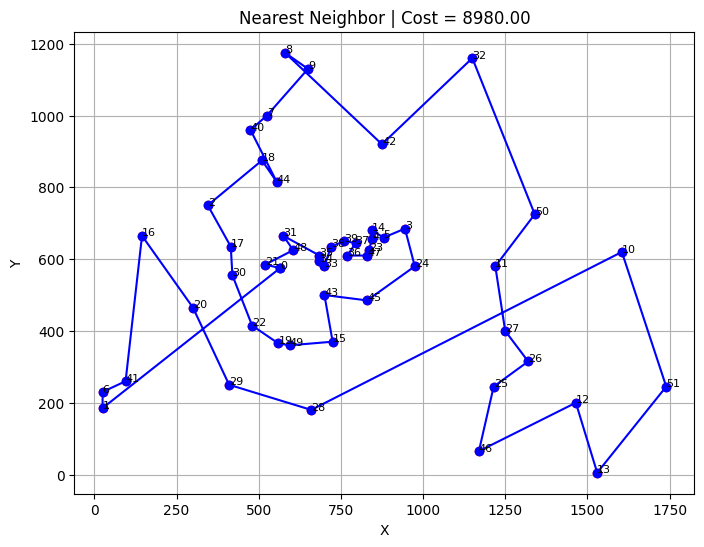

In [21]:
cost_nn = plot_tsp_route(tsp, routes["nn"], "Nearest Neighbor")

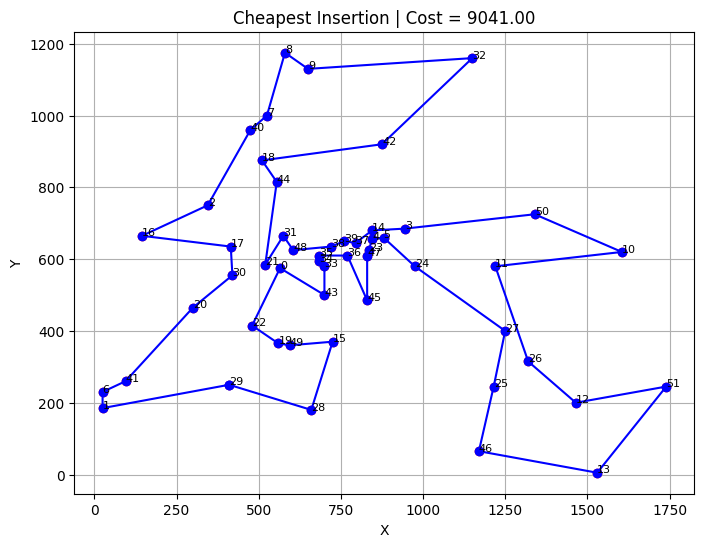

In [22]:
cost_nn = plot_tsp_route(tsp, routes["ci"], "Cheapest Insertion")

# 3. Movimentos de Vizinhança

In [48]:
from src.vnd import vnd, vnd_move_choice
from src.neighborhoods import swap, two_opt 

* Heurística de Construção: NN

In [53]:
initial_route = routes["nn"]

best_route, best_cost, exec_time = vnd_move_choice(
    tsp,
    initial_route,
    neighborhoods = [swap, two_opt],
    verbose=True
)

[swap] improvement: 8901
[swap] improvement: 8840
[swap] improvement: 8780
[swap] improvement: 8765
[swap] improvement: 8751
[swap] improvement: 8619
[swap] improvement: 8614
[two_opt] improvement: 8357
[two_opt] improvement: 8090
[swap] improvement: 8078
[swap] improvement: 8011
[two_opt] improvement: 7826
[two_opt] improvement: 7772
[swap] improvement: 7749


In [54]:
print("Final cost:", best_cost)
print("Execution time:", exec_time)

Final cost: 7749
Execution time: 0.2421431541442871


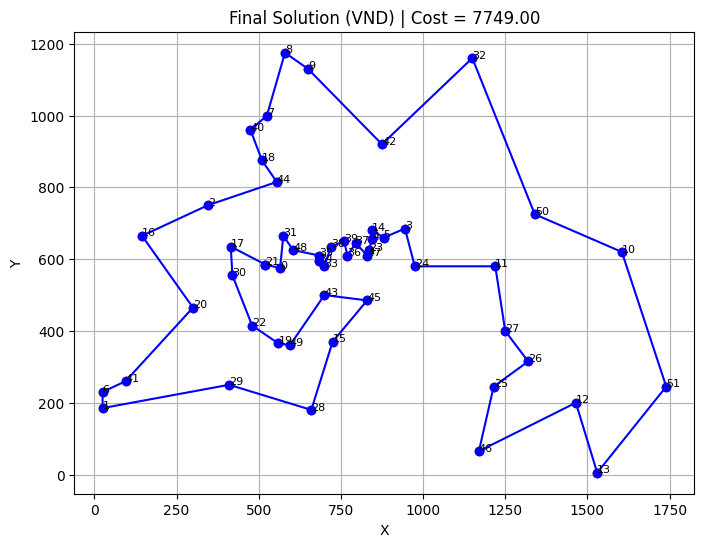

7749

In [34]:
plot_tsp_route(
    tsp,
    best_route,
    title="Final Solution (VND)"
)

* Heurística de Construção: CI

In [50]:
initial_route = routes["ci"]

best_route, best_cost, exec_time = vnd_move_choice(
    tsp,
    initial_route,
    neighborhoods = [swap, two_opt],
    verbose=True
)

[swap] improvement: 8991
[swap] improvement: 8953
[two_opt] improvement: 8923
[two_opt] improvement: 8756
[swap] improvement: 8704
[swap] improvement: 8608
[two_opt] improvement: 8596
[swap] improvement: 8561
[two_opt] improvement: 8507


In [51]:
print("Final cost:", best_cost)
print("Execution time:", exec_time)

Final cost: 8507
Execution time: 0.1857137680053711


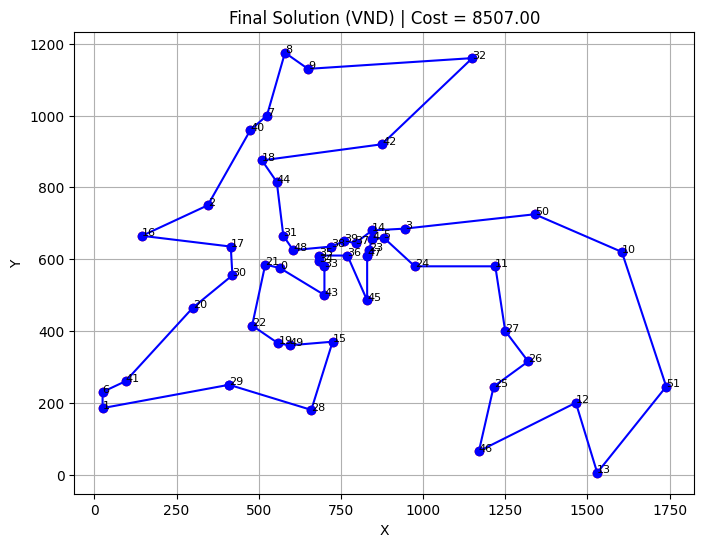

8507

In [52]:
plot_tsp_route(
    tsp,
    best_route,
    title="Final Solution (VND)"
)

* Comentário: NN passou por todas as cidades próximas no centro do gráfico. CI passou duas vezes por esse "núcleo" de cidades.

# 4. Execução Completa

In [60]:
import importlib
import src.utils

importlib.reload(src.utils)


<module 'src.utils' from 'c:\\Users\\USER\\Documents\\notebooks\\estrutura_dados_final\\src\\utils.py'>

In [61]:
from src.tsp import TSP
from src.heuristics import nearest_neighbor
from src.vnd import vnd
from src.utils import run_experiment


# Carregar instância
tsp = TSP.from_tsplib("data/berlin52.tsp")
instance_name = "berlin52"

# Rodar experimento
stats = run_experiment(
    tsp,
    heuristic_func=nearest_neighbor,
    vnd_func=vnd,
    runs=5,
    instance_name=instance_name
)

print("\n===== RESULTADOS =====")
for k, v in stats.items():
    print(f"{k}: {v}")


===== RESULTADOS =====
instance: berlin52
runs: 5
best_cost: 7749
best_solution: [21, 0, 31, 48, 35, 34, 33, 38, 39, 36, 37, 47, 23, 4, 14, 5, 3, 24, 11, 27, 26, 25, 46, 12, 13, 51, 10, 50, 32, 42, 9, 8, 7, 40, 18, 44, 2, 16, 20, 41, 6, 1, 29, 28, 15, 45, 43, 49, 19, 22, 30, 17]
avg_initial_cost: 8980.0
avg_cost: 7749.0
avg_time: 0.22078213691711426
runs_detail: [{'run': 0, 'initial_cost': 8980, 'best_cost': 7749, 'time': 0.22712111473083496, 'initial_solution': [0, 21, 48, 31, 35, 34, 33, 38, 39, 37, 36, 47, 23, 4, 14, 5, 3, 24, 45, 43, 15, 49, 19, 22, 30, 17, 2, 18, 44, 40, 7, 9, 8, 42, 32, 50, 11, 27, 26, 25, 46, 12, 13, 51, 10, 28, 29, 20, 16, 41, 6, 1], 'best_solution': [21, 0, 31, 48, 35, 34, 33, 38, 39, 36, 37, 47, 23, 4, 14, 5, 3, 24, 11, 27, 26, 25, 46, 12, 13, 51, 10, 50, 32, 42, 9, 8, 7, 40, 18, 44, 2, 16, 20, 41, 6, 1, 29, 28, 15, 45, 43, 49, 19, 22, 30, 17]}, {'run': 1, 'initial_cost': 8980, 'best_cost': 7749, 'time': 0.22163820266723633, 'initial_solution': [0, 21, 48, 3

In [62]:
from src.tsp import TSP
from src.heuristics import cheapest_insertion
from src.vnd import vnd
from src.utils import run_experiment


# Carregar instância
tsp = TSP.from_tsplib("data/berlin52.tsp")
instance_name = "berlin52"

# Rodar experimento
stats = run_experiment(
    tsp,
    heuristic_func=cheapest_insertion,
    vnd_func=vnd,
    runs=5,
    instance_name=instance_name
)

print("\n===== RESULTADOS =====")
for k, v in stats.items():
    print(f"{k}: {v}")


===== RESULTADOS =====
instance: berlin52
runs: 5
best_cost: 8507
best_solution: [29, 28, 15, 49, 19, 22, 21, 0, 43, 33, 34, 35, 36, 45, 47, 23, 4, 5, 24, 11, 27, 26, 25, 46, 12, 13, 51, 10, 50, 3, 14, 37, 39, 38, 48, 31, 44, 18, 42, 32, 9, 8, 7, 40, 2, 16, 17, 30, 20, 41, 6, 1]
avg_initial_cost: 9041.0
avg_cost: 8507.0
avg_time: 0.1794759750366211
runs_detail: [{'run': 0, 'initial_cost': 9041, 'best_cost': 8507, 'time': 0.24408531188964844, 'initial_solution': [29, 28, 15, 49, 19, 22, 0, 43, 33, 34, 35, 36, 45, 47, 23, 4, 5, 24, 27, 25, 46, 13, 51, 12, 26, 11, 10, 50, 3, 14, 37, 39, 38, 48, 31, 21, 44, 18, 42, 32, 9, 8, 7, 40, 2, 16, 17, 30, 20, 41, 6, 1], 'best_solution': [29, 28, 15, 49, 19, 22, 21, 0, 43, 33, 34, 35, 36, 45, 47, 23, 4, 5, 24, 11, 27, 26, 25, 46, 12, 13, 51, 10, 50, 3, 14, 37, 39, 38, 48, 31, 44, 18, 42, 32, 9, 8, 7, 40, 2, 16, 17, 30, 20, 41, 6, 1]}, {'run': 1, 'initial_cost': 9041, 'best_cost': 8507, 'time': 0.1619112491607666, 'initial_solution': [29, 28, 15, 49

# 5. Outras Instâncias

In [64]:
from src.tsp import TSP
from src.heuristics import nearest_neighbor
from src.vnd import vnd
from src.utils import run_experiment


# Carregar instância
tsp = TSP.from_tsplib("data/kroA100.tsp")
instance_name = "kroA100"

# Rodar experimento
stats = run_experiment(
    tsp,
    heuristic_func=nearest_neighbor,
    vnd_func=vnd,
    runs=5,
    instance_name=instance_name
)

print("\n===== RESULTADOS =====")
for k, v in stats.items():
    print(f"{k}: {v}")


===== RESULTADOS =====
instance: kroA100
runs: 5
best_cost: 21919
best_solution: [91, 0, 46, 92, 27, 66, 57, 60, 24, 80, 68, 63, 39, 53, 1, 43, 49, 72, 67, 84, 38, 81, 94, 12, 75, 32, 36, 4, 51, 77, 95, 29, 47, 99, 40, 70, 13, 2, 42, 45, 28, 33, 82, 54, 6, 8, 86, 50, 56, 19, 11, 26, 85, 34, 61, 59, 76, 22, 97, 90, 44, 31, 10, 14, 16, 58, 73, 20, 71, 83, 9, 89, 48, 5, 62, 74, 18, 52, 78, 17, 23, 37, 35, 98, 93, 87, 15, 21, 69, 65, 25, 64, 3, 96, 55, 79, 30, 88, 41, 7]
avg_initial_cost: 27807.0
avg_cost: 21919.0
avg_time: 3.489467477798462
runs_detail: [{'run': 0, 'initial_cost': 27807, 'best_cost': 21919, 'time': 3.492331027984619, 'initial_solution': [0, 62, 5, 48, 89, 9, 83, 71, 20, 73, 58, 16, 14, 10, 31, 90, 97, 22, 44, 46, 92, 27, 66, 57, 60, 24, 80, 68, 72, 49, 43, 1, 53, 39, 63, 67, 84, 38, 29, 95, 77, 51, 4, 36, 32, 75, 12, 94, 81, 47, 99, 70, 40, 13, 2, 45, 28, 33, 82, 54, 11, 26, 85, 34, 19, 56, 6, 8, 86, 50, 76, 59, 61, 42, 7, 91, 74, 18, 52, 78, 17, 23, 37, 35, 98, 93, 21, 

In [65]:
from src.tsp import TSP
from src.heuristics import cheapest_insertion
from src.vnd import vnd
from src.utils import run_experiment


# Carregar instância
tsp = TSP.from_tsplib("data/kroA100.tsp")
instance_name = "kroA100"

# Rodar experimento
stats = run_experiment(
    tsp,
    heuristic_func=cheapest_insertion,
    vnd_func=vnd,
    runs=5,
    instance_name=instance_name
)

print("\n===== RESULTADOS =====")
for k, v in stats.items():
    print(f"{k}: {v}")


===== RESULTADOS =====
instance: kroA100
runs: 5
best_cost: 24219
best_solution: [43, 49, 81, 94, 12, 75, 32, 36, 4, 38, 95, 77, 51, 47, 99, 40, 70, 13, 2, 42, 45, 28, 29, 84, 67, 72, 68, 80, 24, 8, 6, 33, 82, 54, 11, 26, 85, 34, 61, 59, 22, 44, 14, 16, 10, 31, 46, 90, 97, 76, 19, 56, 86, 50, 60, 57, 27, 92, 0, 62, 5, 48, 89, 78, 83, 9, 71, 20, 73, 58, 35, 98, 37, 23, 17, 93, 21, 69, 15, 87, 52, 18, 65, 25, 64, 3, 96, 55, 74, 91, 7, 41, 79, 30, 88, 66, 63, 39, 53, 1]
avg_initial_cost: 25230.0
avg_cost: 24219.0
avg_time: 1.0548568725585938
runs_detail: [{'run': 0, 'initial_cost': 25230, 'best_cost': 24219, 'time': 1.0690066814422607, 'initial_solution': [43, 49, 81, 94, 12, 75, 32, 38, 36, 4, 95, 77, 51, 47, 99, 40, 70, 13, 2, 42, 45, 28, 29, 84, 67, 72, 63, 66, 88, 30, 79, 41, 7, 91, 74, 55, 96, 3, 64, 25, 65, 18, 52, 15, 69, 21, 93, 87, 17, 23, 37, 98, 35, 58, 73, 20, 71, 83, 9, 78, 89, 48, 5, 62, 0, 92, 27, 57, 60, 50, 86, 56, 19, 76, 97, 90, 46, 31, 10, 16, 14, 44, 22, 59, 61, 85, 

In [66]:
from src.tsp import TSP
from src.heuristics import nearest_neighbor
from src.vnd import vnd
from src.utils import run_experiment


# Carregar instância
tsp = TSP.from_tsplib("data/st70.tsp")
instance_name = "st70"

# Rodar experimento
stats = run_experiment(
    tsp,
    heuristic_func=nearest_neighbor,
    vnd_func=vnd,
    runs=5,
    instance_name=instance_name
)

print("\n===== RESULTADOS =====")
for k, v in stats.items():
    print(f"{k}: {v}")


===== RESULTADOS =====
instance: st70
runs: 5
best_cost: 701
best_solution: [22, 35, 0, 15, 46, 36, 57, 49, 51, 9, 4, 52, 5, 40, 42, 16, 20, 33, 11, 59, 50, 55, 64, 63, 10, 47, 66, 32, 53, 61, 38, 24, 44, 60, 39, 45, 26, 8, 67, 43, 29, 19, 13, 27, 7, 25, 48, 54, 18, 6, 31, 2, 41, 17, 3, 1, 23, 14, 56, 34, 69, 28, 12, 30, 68, 37, 58, 62, 65, 21]
avg_initial_cost: 830.0
avg_cost: 701.0
avg_time: 0.6725352287292481
runs_detail: [{'run': 0, 'initial_cost': 830, 'best_cost': 701, 'time': 0.6660847663879395, 'initial_solution': [0, 35, 22, 46, 15, 36, 57, 49, 9, 4, 52, 65, 21, 62, 58, 37, 68, 30, 12, 28, 69, 34, 56, 14, 23, 1, 6, 31, 2, 7, 27, 25, 48, 54, 18, 3, 17, 41, 5, 40, 42, 16, 20, 33, 11, 59, 51, 50, 55, 64, 10, 47, 66, 53, 32, 61, 38, 44, 24, 39, 60, 8, 26, 45, 67, 43, 29, 19, 13, 63], 'best_solution': [22, 35, 0, 15, 46, 36, 57, 49, 51, 9, 4, 52, 5, 40, 42, 16, 20, 33, 11, 59, 50, 55, 64, 63, 10, 47, 66, 32, 53, 61, 38, 24, 44, 60, 39, 45, 26, 8, 67, 43, 29, 19, 13, 27, 7, 25, 48,

In [67]:
from src.tsp import TSP
from src.heuristics import cheapest_insertion
from src.vnd import vnd
from src.utils import run_experiment


# Carregar instância
tsp = TSP.from_tsplib("data/st70.tsp")
instance_name = "st70"

# Rodar experimento
stats = run_experiment(
    tsp,
    heuristic_func=cheapest_insertion,
    vnd_func=vnd,
    runs=5,
    instance_name=instance_name
)

print("\n===== RESULTADOS =====")
for k, v in stats.items():
    print(f"{k}: {v}")


===== RESULTADOS =====
instance: st70
runs: 5
best_cost: 719
best_solution: [3, 17, 41, 5, 40, 42, 16, 8, 26, 45, 39, 44, 24, 38, 60, 33, 20, 11, 61, 53, 47, 66, 10, 63, 64, 50, 55, 32, 59, 51, 9, 49, 36, 57, 4, 52, 65, 21, 37, 22, 46, 15, 0, 35, 28, 12, 69, 34, 30, 68, 58, 62, 56, 14, 23, 18, 6, 25, 54, 48, 7, 27, 13, 19, 29, 67, 43, 2, 31, 1]
avg_initial_cost: 744.0
avg_cost: 719.0
avg_time: 0.25330362319946287
runs_detail: [{'run': 0, 'initial_cost': 744, 'best_cost': 719, 'time': 0.25444984436035156, 'initial_solution': [3, 17, 41, 40, 5, 42, 16, 8, 26, 45, 39, 44, 24, 38, 60, 20, 33, 11, 61, 53, 47, 66, 10, 63, 64, 50, 55, 32, 59, 51, 9, 49, 36, 57, 4, 52, 65, 58, 37, 68, 30, 34, 69, 12, 28, 35, 0, 15, 46, 22, 21, 62, 56, 14, 23, 18, 6, 25, 54, 48, 7, 27, 19, 29, 13, 67, 43, 2, 31, 1], 'best_solution': [3, 17, 41, 5, 40, 42, 16, 8, 26, 45, 39, 44, 24, 38, 60, 33, 20, 11, 61, 53, 47, 66, 10, 63, 64, 50, 55, 32, 59, 51, 9, 49, 36, 57, 4, 52, 65, 21, 37, 22, 46, 15, 0, 35, 28, 12, 6

# 6. Comparação de soluções - Berlin52

In [69]:
# Carregar instância
tsp = TSP.from_tsplib("data/berlin52.tsp")
instance_name = "berlin52"

# Rodar experimento
stats = run_experiment(
    tsp,
    heuristic_func=nearest_neighbor,
    vnd_func=vnd,
    runs=5,
    instance_name=instance_name
)

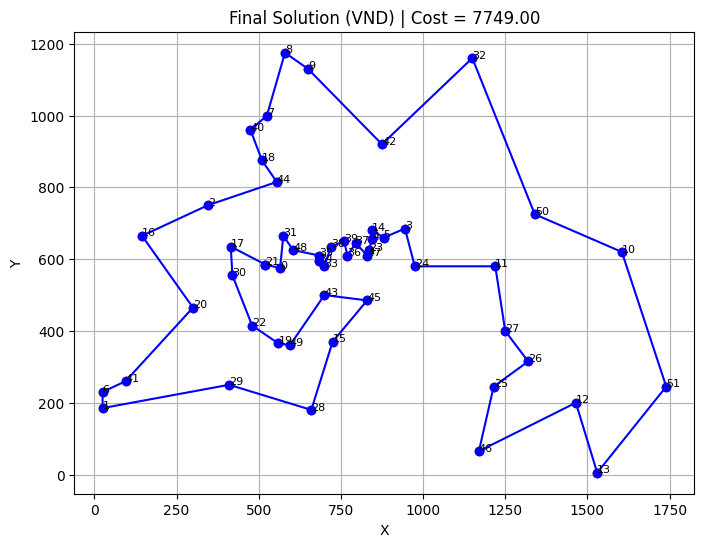

7749

In [70]:
plot_tsp_route(
    tsp,
    best_route,
    title="Final Solution (VND)"
)

* Na literatura, a busca pela melhor solução do dataset Berlin52 resulta na seguinte composição:

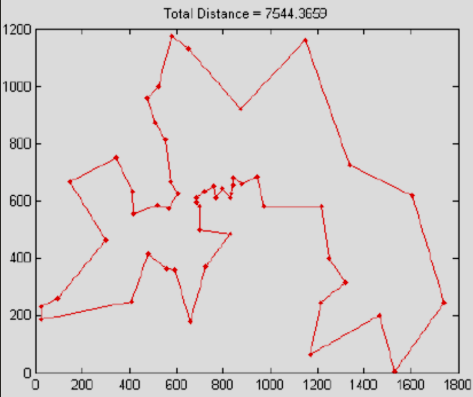






Vemos que a melhor solução encontrada aqui foi 7749. Já a solução acima encontrou menor custo em 7544.

Fonte: DAVIS, Ethan. Exploration-Exploitation-Evaluation (EEE): A Framework for Metaheuristic Algorithms in Combinatorial Optimization. 2025. Disponível em: https://doi.org/10.48550/arXiv.2510.05027. Acesso em: 2026.

Ver também: https://www.kaggle.com/code/alperenw/metaheuristic-opt-berlin52-tsp-aco-sa-optimal

Ver também: ABDOUN, Otman; TAJANI, Chakir; ABOUCHABAKA, Jaafar. Hybridizing PSM and RSM Operator for Solving NP-Complete Problems: Application to Travelling Salesman Problem. International Journal of Computer Science Issues, v. 9, 2012.

Disponível em: https://www.researchgate.net/publication/221901574_Hybridizing_PSM_and_RSM_Operator_for_Solving_NP-Complete_ProblemsApplication_to_Travelling_Salesman_Problem